# Bibliotecas

Importando os pacotes necessários para o código

In [243]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Base NPS

Importando o CSV

In [244]:
df_nps = pd.read_csv("../data/desafio_nps_fase_1.csv")

## Conhecendo a Base

Avaliação inicial da qualidade dos dados:
* Não possuímos valores nulos;
* As colunas estão nos formatos apropriados, de inteiro ou float, com exceção da coluna de região (texto);
* Não há mais de uma avaliação por clientes, pois os ID's são únicos. O ID de compra também é único


In [245]:
df_nps.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

In [246]:
df_nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [247]:
df_nps.nunique()

customer_id                  2500
customer_age                   52
customer_region                 5
customer_tenure_months        119
order_id                     2500
order_value                  2457
items_quantity                  6
discount_value               2050
payment_installments           11
delivery_time_days             13
delivery_delay_days             9
freight_value                1897
delivery_attempts               3
customer_service_contacts       8
resolution_time_days           12
nps_score                     101
repeat_purchase_30d             2
complaints_count               12
csat_internal_score            98
dtype: int64

In [248]:
df_nps.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


## Criação de Variáveis

Função para classificar o NPS

In [249]:
def classificar_nps(nota):

    if pd.isna(nota):
        return np.nan

    elif nota < 7:
        return "Detrator"

    elif nota < 9:
        return "Neutro"

    else:
        return "Promotor"

In [250]:
df_nps["nps_classe"] = df_nps["nps_score"].apply(classificar_nps)

Criando faixas para as idades

In [251]:
def faixa_etaria(idade):

    if pd.isna(idade):
        return np.nan

    elif idade < 25:
        return "18-24"

    elif idade < 35:
        return "25-34"

    elif idade < 45:
        return "35-44"

    elif idade < 55:
        return "45-54"

    elif idade < 65:
        return "55-64"

    else:
        return "65+"

In [252]:
df_nps["faixa_etaria"] = df_nps["customer_age"].apply(faixa_etaria)

Faixa de relacionamento

In [253]:
def classificar_tenure(meses):

    if pd.isna(meses):
        return np.nan

    elif meses <= 12:
        return "Novo"

    elif meses <= 36:
        return "Médio"

    else:
        return "Antigo"

In [254]:
df_nps["perfil_cliente"] = df_nps["customer_tenure_months"].apply(classificar_tenure)

Faixa de frete

In [255]:
def faixa_frete(valor):

    if pd.isna(valor):
        return np.nan
    elif valor == 0:
        return "Frete grátis"
    elif valor <= 15:
        return "Até R$15"
    elif valor <= 30:
        return "R$15–30"
    elif valor <= 50:
        return "R$30–50"
    else:
        return "Acima de R$50"

In [256]:
df_nps["faixa_frete"] = df_nps["freight_value"].apply(faixa_frete)

Faixa de tempo de entrega

In [257]:
def faixa_tempo_entrega(dias):

    if pd.isna(dias):
        return np.nan
    elif dias <= 2:
        return "0–2 dias"
    elif dias <= 5:
        return "3–5 dias"
    elif dias <= 10:
        return "6–10 dias"
    elif dias <= 15:
        return "11–15 dias"
    else:
        return "15+ dias"

In [258]:
df_nps["faixa_tempo_entrega"] = df_nps["delivery_time_days"].apply(faixa_tempo_entrega)

Faixa de Atraso

In [259]:
def faixa_atraso(x):

    if pd.isna(x):
        return np.nan

    elif x == 0:
        return '0'

    elif x == 1:
        return '1'

    elif x == 2:
        return '2'

    elif x == 3:
        return '3'

    elif x == 4:
        return '4'

    else:
        return '5+'

In [260]:
df_nps['faixa_atraso'] = df_nps['delivery_delay_days'].apply(faixa_atraso)

Faixa Reclamações

In [261]:
def faixa_reclamacoes(x):

    if pd.isna(x):
        return np.nan

    elif x == 0:
        return '0'

    elif x == 1:
        return '1'

    elif x == 2:
        return '2'

    elif x == 3:
        return '3'

    elif x == 4:
        return '4'

    elif x == 5:
        return '5'

    else:
        return '6+'


In [262]:
df_nps['faixa_reclamacoes'] = df_nps['complaints_count'].apply(faixa_reclamacoes)

Faixa de Contatos

In [263]:
def faixa_contatos(x):

    if pd.isna(x):
        return np.nan

    elif x == 0:
        return '0'

    elif x == 1:
        return '1'

    elif x == 2:
        return '2'

    elif x == 3:
        return '3'

    else:
        return '4+'

In [264]:
df_nps['faixa_contatos'] = df_nps['customer_service_contacts'].apply(faixa_contatos)

Flags

In [265]:
# Flag de avaliador
df_nps["flg_avaliou_nps"] = df_nps["nps_score"].notna().astype(int)

# Flag de nota detratora
df_nps["flg_detrator"] = np.where(df_nps["nps_score"] < 7, 1, 0)

# Flag de desconto na compra
df_nps["flg_desconto"] = np.where(df_nps["discount_value"] > 0, 1, 0)

# Flag de atraso na entrega
df_nps["flg_atraso"] = np.where(df_nps["delivery_delay_days"] > 0, 1, 0)

# Flag de atraso na entrega
df_nps["flg_reclamou"] = np.where(df_nps["complaints_count"] > 0, 1, 0)

# Visualizações

## Percentuais para contextualização da base

In [266]:
flags = [
    "flg_atraso",
    "flg_reclamou",
    "repeat_purchase_30d",

    "flg_detrator",
    "flg_avaliou_nps",
    "flg_desconto",
]

percentuais = (
    df_nps[flags]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

percentuais.columns = ["flag", "percentual"]

print(percentuais)

                  flag  percentual
0           flg_atraso       88.92
1         flg_reclamou       99.08
2  repeat_purchase_30d        8.72
3         flg_detrator       84.36
4      flg_avaliou_nps      100.00
5         flg_desconto      100.00


## Régua de NPS

In [267]:
nps_dist = (
    df_nps["nps_score"]
    .astype(int)
    .value_counts()
    .reindex(range(11), fill_value=0)
    .sort_index()
    .reset_index()
)

nps_dist.columns = ["nps_score", "qtd"]

nps_dist["percentual"] = (
    nps_dist["qtd"]
    / nps_dist["qtd"].sum()
    * 100
).round(1)

nps_dist

,nps_score,qtd,percentual
0,0,272,10.9
1,1,191,7.6
2,2,286,11.4
3,3,339,13.6
4,4,378,15.1
5,5,351,14.0
6,6,292,11.7
7,7,173,6.9
8,8,108,4.3
9,9,68,2.7


## Barras - Distribuições Clientes

Gráfico de Barras: Distribuiçlão por faixa de idade dos clientes

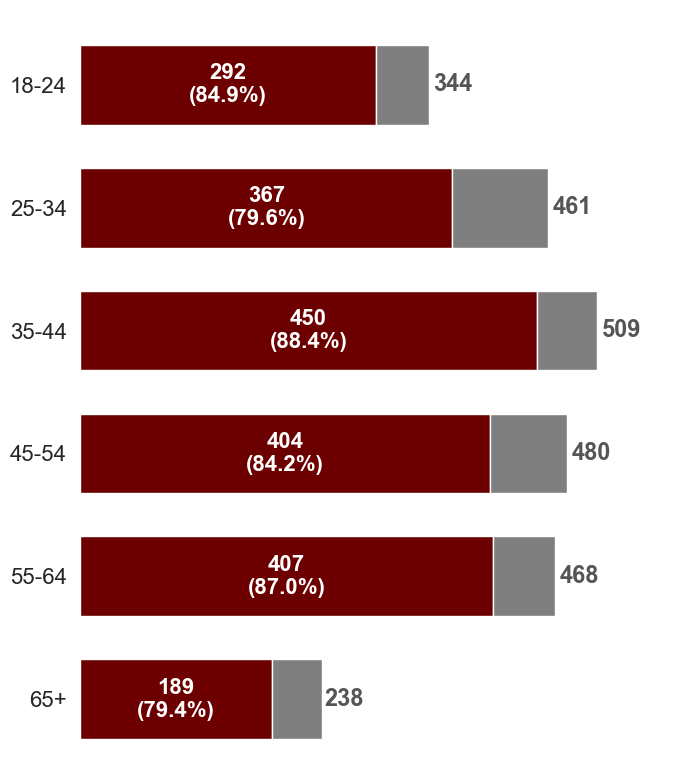

In [268]:
#### Preparação dos dados
graf = (
    df_nps.groupby("faixa_etaria")
    .agg(
        total=("flg_avaliou_nps", "sum"),
        detratores=("flg_detrator", "sum")
    )
    .reset_index()
)

graf["nao_detratores"] = (
    graf["total"] - graf["detratores"]
)

graf["pct_detrator"] = (
    graf["detratores"]
    / graf["total"]
    * 100
).round(1)

ordem = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

graf["faixa_etaria"] = pd.Categorical(
    graf["faixa_etaria"],
    categories=ordem,
    ordered=True
)

graf = (
    graf
    .sort_values("faixa_etaria", ascending=False)
    .reset_index(drop=True)
)


#### Gráfico ####

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(7, 8))

cor_detrator = "#6C0000"
cor_demais = "#7F7F7F"

# Barras
ax.barh(
    graf["faixa_etaria"],
    graf["detratores"],
    color=cor_detrator,
    height=0.65
)

ax.barh(
    graf["faixa_etaria"],
    graf["nao_detratores"],
    left=graf["detratores"],
    color=cor_demais,
    height=0.65
)


#### Rótulos

for pos, row in graf.iterrows():

    det = int(row["detratores"])
    total = int(row["total"])
    pct = row["pct_detrator"]

    # rótulo dentro da barra vermelha
    if det > 0:
        ax.text(
            det/2,
            pos,
            f"{det}\n({pct:.1f}%)",
            ha="center",
            va="center",
            fontsize=16,
            color="white",
            fontweight="bold"
        )

    # total no final da barra
    ax.text(
        total * 1.01,
        pos,
        f"{total:,.0f}".replace(",", "."),
        ha="left",
        va="center",
        fontsize=17,
        color="#555555",
        fontweight="bold"
    )


#### Estilo

ax.set_xlabel("")
ax.set_ylabel("")

# remove números do eixo X
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=16)

# remove grades
ax.grid(False)

# remove contornos
sns.despine(
    left=True,
    bottom=True
)

# remove tracinhos
ax.tick_params(left=False)

# espaço para os totais
ax.set_xlim(0, graf["total"].max() * 1.15)

plt.tight_layout()

plt.show()

Gráfico de Barras: Distribuiçlão por tempo de relacionamento

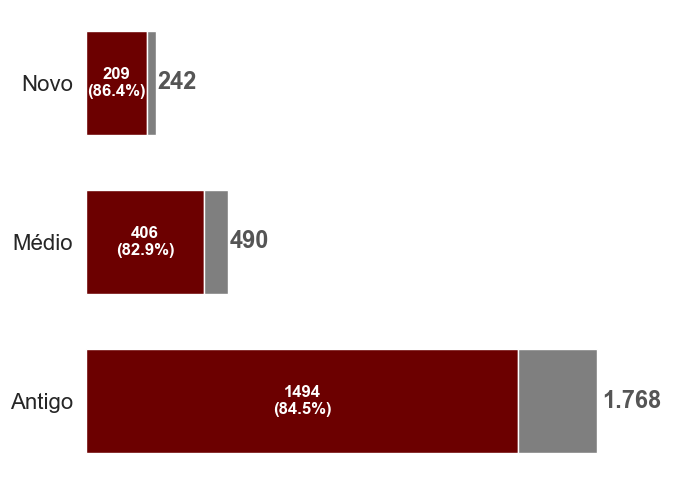

In [269]:
#### Preparação dos dados

graf = (
    df_nps.groupby("perfil_cliente")
    .agg(
        total=("flg_avaliou_nps", "sum"),
        detratores=("flg_detrator", "sum")
    )
    .reset_index()
)

graf["nao_detratores"] = (
    graf["total"] - graf["detratores"]
)

graf["pct_detrator"] = (
    graf["detratores"]
    / graf["total"]
    * 100
).round(1)

ordem = ['Novo', 'Médio', 'Antigo']

graf["perfil_cliente"] = pd.Categorical(
    graf["perfil_cliente"],
    categories=ordem,
    ordered=True
)

graf = (
    graf
    .sort_values("perfil_cliente", ascending=False)
    .reset_index(drop=True)
)


#### Gráfico

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(7, 5))

cor_detrator = "#6C0000"
cor_demais = "#7F7F7F"

ax.barh(
    graf["perfil_cliente"],
    graf["detratores"],
    color=cor_detrator,
    height=0.65
)

ax.barh(
    graf["perfil_cliente"],
    graf["nao_detratores"],
    left=graf["detratores"],
    color=cor_demais,
    height=0.65
)


#### Rótulos

for pos, row in graf.iterrows():

    det = int(row["detratores"])
    total = int(row["total"])
    pct = row["pct_detrator"]

    if det > total * 0.25:
        ax.text(
            det/2,
            pos,
            f"{det}\n({pct:.1f}%)",
            ha="center",
            va="center",
            fontsize=12,
            color="white",
            fontweight="bold"
        )

    ax.text(
        total * 1.01,
        pos,
        f"{total:,.0f}".replace(",", "."),
        ha="left",
        va="center",
        fontsize=17,
        color="#555555",
        fontweight="bold"
    )


#### Estilo

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticks([])

ax.tick_params(
    axis='y',
    labelsize=16
)

ax.grid(False)

sns.despine(
    left=True,
    bottom=True
)

ax.tick_params(left=False)

ax.set_xlim(
    0,
    graf["total"].max() * 1.15
)

plt.tight_layout()

plt.show()

Gráfico de Barras: Distribuiçlão por região do país

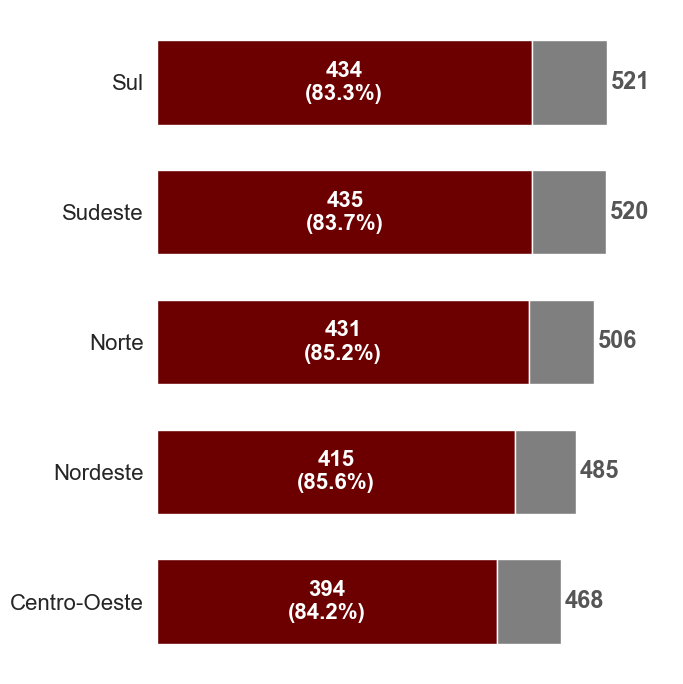

In [270]:
#### Preparação dos dados

graf = (
    df_nps.groupby("customer_region")
    .agg(
        total=("flg_avaliou_nps", "sum"),
        detratores=("flg_detrator", "sum")
    )
    .reset_index()
)

graf["nao_detratores"] = (
    graf["total"] - graf["detratores"]
)

graf["pct_detrator"] = (
    graf["detratores"]
    / graf["total"]
    * 100
).round(1)

# Ordena da região com mais avaliações para a com menos avaliações
graf = (
    graf
    .sort_values("total", ascending=True)
    .reset_index(drop=True)
)


#### Gráfico ####

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(7, 7))

cor_detrator = "#6C0000"
cor_demais = "#7F7F7F"

# Barras
ax.barh(
    graf["customer_region"],
    graf["detratores"],
    color=cor_detrator,
    height=0.65
)

ax.barh(
    graf["customer_region"],
    graf["nao_detratores"],
    left=graf["detratores"],
    color=cor_demais,
    height=0.65
)


#### Rótulos

for pos, row in graf.iterrows():

    det = int(row["detratores"])
    total = int(row["total"])
    pct = row["pct_detrator"]

    # rótulo dentro da barra vermelha quando há espaço suficiente
    if det > total * 0.25:

        ax.text(
            det/2,
            pos,
            f"{det}\n({pct:.1f}%)",
            ha="center",
            va="center",
            fontsize=16,
            color="white",
            fontweight="bold"
        )

    # rótulo fora da barra quando ela é pequena
    else:

        ax.text(
            det + total*0.02,
            pos,
            f"{det} ({pct:.1f}%)",
            ha="left",
            va="center",
            fontsize=14,
            color=cor_detrator,
            fontweight="bold"
        )

    # total ao final da barra
    ax.text(
        total * 1.01,
        pos,
        f"{total:,.0f}".replace(",", "."),
        ha="left",
        va="center",
        fontsize=17,
        color="#555555",
        fontweight="bold"
    )


#### Estilo

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticks([])
ax.tick_params(axis='y', labelsize=16)

ax.grid(False)

sns.despine(
    left=True,
    bottom=True
)

ax.tick_params(left=False)

ax.set_xlim(
    0,
    graf["total"].max() * 1.15
)

plt.tight_layout()

plt.show()

Análise de Variáveis de Negócio

In [271]:

# Variáveis que eu quero analisar:
vars_negocio = [
'order_value',
'items_quantity',
'discount_value',
'payment_installments',
'delivery_time_days',
'delivery_delay_days',
'freight_value',
'delivery_attempts',
'customer_service_contacts',
'resolution_time_days',
'complaints_count'
]


# Mapping para renomear as variáveis no gráfico, tornando-o mais executivo
mapa_nomes = {
    'order_value': 'Valor do Pedido',
    'items_quantity': 'Qtd. de Itens',
    'discount_value': 'Valor do Desconto',
    'payment_installments': 'Parcelamento',
    'delivery_time_days': 'Tempo de Entrega',
    'delivery_delay_days': 'Dias de Atraso',
    'freight_value': 'Valor do Frete',
    'delivery_attempts': 'Tentativas de Entrega',
    'customer_service_contacts': 'Contatos com Atendimento',
    'resolution_time_days': 'Tempo de Resolução',
    'complaints_count': 'Reclamações'
}

## Correlação entre NPS e essas variáveis

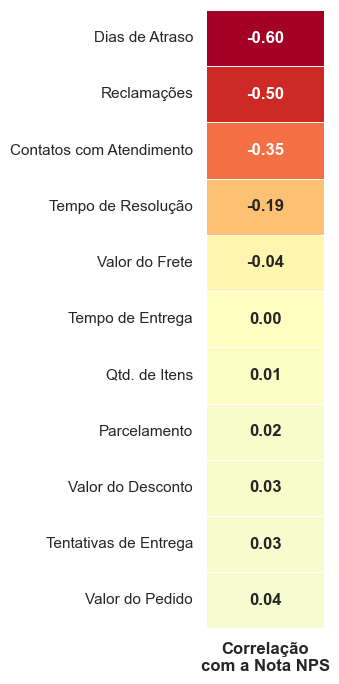

In [272]:
corr = (
    df_nps[vars_negocio + ['nps_score']]
    .corr(numeric_only=True)
)

corr_plot = (
    corr[['nps_score']]
    .drop('nps_score')
    .sort_values('nps_score')
    .rename(index=mapa_nomes)
)

plt.figure(figsize=(3.5, 7))

ax = sns.heatmap(
    corr_plot,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu',
    center=0,
    linewidths=.5,
    cbar=False,
    annot_kws={'fontsize':12, 'fontweight':'bold'}
)

ax.set_xticklabels(
    ['Correlação\ncom a Nota NPS'],
    fontsize=12,
    fontweight='bold'
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=11
)


plt.ylabel('')
plt.xlabel('')

plt.tight_layout()

plt.show()

## Taxas de Detratores

Função para reprodução de gráficos padronizados

In [273]:
def grafico_detratores(df,
                       coluna,
                       ordem):

    graf = (
        df
        .groupby(coluna)
        .agg(
            total=('flg_avaliou_nps','sum'),
            detratores=('flg_detrator','sum')
        )
        .reset_index()
    )

    graf['pct'] = (
        graf['detratores']
        / graf['total']
        * 100
    )

    graf[coluna] = pd.Categorical(
        graf[coluna],
        categories=ordem,
        ordered=True
    )

    graf = (
        graf
        .sort_values(coluna)
        .reset_index(drop=True)
    )

    sns.set_theme(style='white')

    fig, ax = plt.subplots(
        figsize=(5,4)
    )

    cor = '#6C0000'

    bars = sns.barplot(
        data=graf,
        y=coluna,
        x='pct',
        color=cor,
        ax=ax
    )

    for i,row in graf.iterrows():

        pct = row['pct']
        qtd = int(row['detratores'])

        ax.text(
            pct+1,
            i,
            f'{pct:.1f}% ({qtd})',
            va='center',
            fontsize=11,
            fontweight='bold',
            color='#333333'
        )

    ax.set_xlabel('')
    ax.set_ylabel('')

    ax.set_xticks([])

    ax.grid(False)

    sns.despine(
        left=True,
        bottom=True
    )

    ax.tick_params(
        left=False,
        labelsize=11
    )

    ax.set_xlim(
        0,
        graf['pct'].max()*1.20
    )

    plt.tight_layout()

    plt.show()

Taxa de detratores por dia de atraso

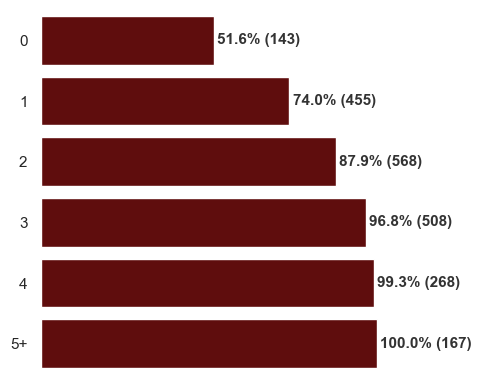

In [274]:
grafico_detratores(

    df_nps,

    coluna='faixa_atraso',

    ordem=[
        '0',
        '1',
        '2',
        '3',
        '4',
        '5+'
    ]

)

Taxa de detratores por quantidade de reclamações

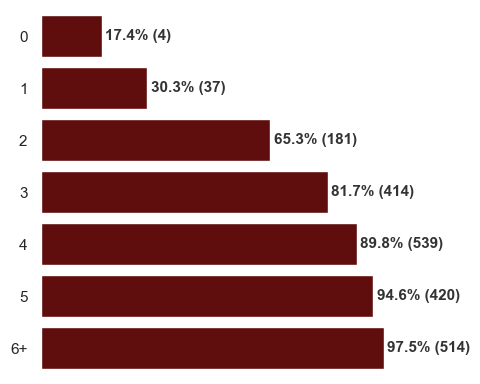

In [275]:
grafico_detratores(

    df_nps,

    coluna='faixa_reclamacoes',

    ordem=[
        '0',
        '1',
        '2',
        '3',
        '4',
        '5',
        '6+'
    ]
)

Taxa de detratores por contatos com atendimento

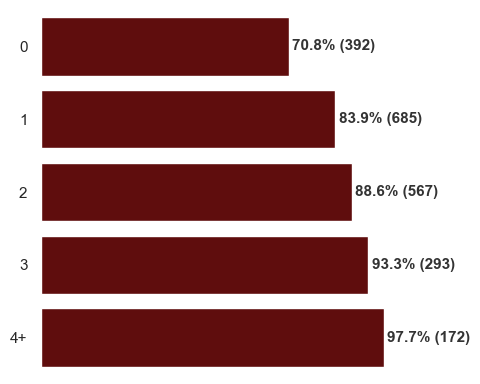

In [276]:
grafico_detratores(

    df_nps,

    coluna='faixa_contatos',

    ordem=[
        '0',
        '1',
        '2',
        '3',
        '4+'
    ]

)

## Matriz de Atraso e Atendimento

Funções para criar os grupos da matriz

In [277]:
def grupo_atraso_matriz(x):

    if pd.isna(x):
        return np.nan

    elif x == 0:
        return 'Sem atraso'

    elif x <= 2:
        return '1-2 dias'

    elif x <= 5:
        return '3-5 dias'

    else:
        return '6+ dias'
    

def grupo_contato_matriz(x):

    if pd.isna(x):
        return np.nan

    elif x == 0:
        return '0 contatos'

    elif x == 1:
        return '1 contato'

    else:
        return '2+ contatos'

In [278]:
df_nps['grupo_atraso_matriz'] = df_nps['delivery_delay_days'].apply(grupo_atraso_matriz)

df_nps['grupo_contato_matriz'] = df_nps['customer_service_contacts'].apply(grupo_contato_matriz)

In [280]:
matriz = (
    df_nps
    .groupby(['grupo_atraso_matriz', 'grupo_contato_matriz'])
    .agg(
        pct_detrator=('flg_detrator',
                      lambda x: x.mean()*100),
        qtd_detratores=('flg_detrator',
                        'sum')
    )
    .reset_index()
)

matriz['texto'] = (
    matriz['pct_detrator']
    .round(1)
    .astype(str)
    + '% ('
    + matriz['qtd_detratores']
        .astype(int)
        .astype(str)
    + ')'
)

matriz = matriz.pivot(
    index='grupo_atraso_matriz',
    columns='grupo_contato_matriz',
    values='texto'
)

ordem_linhas = [
    'Sem atraso',
    '1-2 dias',
    '3-5 dias',
    '6+ dias'
]

ordem_colunas = [
    '0 contatos',
    '1 contato',
    '2+ contatos'
]

matriz = matriz.loc[
    ordem_linhas,
    ordem_colunas
]

matriz

grupo_contato_matriz,0 contatos,1 contato,2+ contatos
grupo_atraso_matriz,,,
Sem atraso,21.5% (14),45.0% (36),70.5% (93)
1-2 dias,64.6% (173),79.2% (323),90.1% (527)
3-5 dias,92.5% (196),99.3% (303),99.7% (393)
6+ dias,100.0% (9),100.0% (23),100.0% (19)
